# 01 Exploratory Data Analysis: Swahili News Classification

This notebook explores the Zindi Swahili News Classification data. Each section ends with what the finding means for our models.

1. Setup
2. Data quality issues and cleaning
3. Class distribution
4. Article length
5. Subword token length (for the transformer)
6. Vocabulary and rare words
7. Common words and distinctive words per class
8. Summary of findings

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    !pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /Users/michael/Documents/school/nlp_language_technologies


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config
from src import data_cleaning
from src import data_loading

sns.set_theme(style="whitegrid")

EDA_FIGURES_DIRECTORY = config.FIGURES_DIRECTORY / "eda"
EDA_FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)


def save_figure(file_name):
    plt.tight_layout()
    plt.savefig(EDA_FIGURES_DIRECTORY / file_name, dpi=150)
    plt.show()

In [3]:
if not config.TRAIN_FILE.exists():
    data_cleaning.main()

raw_train = pd.read_csv(config.RAW_TRAIN_FILE)
raw_test = pd.read_csv(config.RAW_TEST_FILE)

train = data_loading.load_train()
validation = data_loading.load_validation()
test = data_loading.load_test()
zindi_test = data_loading.load_zindi_test()

all_labelled = pd.concat([train, validation, test], ignore_index=True)

print("Raw train articles:", len(raw_train))
print("Raw Zindi test articles:", len(raw_test))
print("Cleaned labelled articles:", len(all_labelled))
print("Split sizes:", len(train), len(validation), len(test))

Raw train articles: 5151
Raw Zindi test articles: 1288
Cleaned labelled articles: 5148
Split sizes: 3603 772 773


In [4]:
raw_train.head()

,id,content,category
0,SW0,SERIKALI imesema haitakuwa tayari kuona amani...,Kitaifa
1,SW1,"Mkuu wa Mkoa wa Tabora, Aggrey Mwanri amesiti...",Biashara
2,SW10,SERIKALI imetoa miezi sita kwa taasisi zote z...,Kitaifa
3,SW100,KAMPUNI ya mchezo wa kubahatisha ya M-bet ime...,michezo
4,SW1000,WATANZANIA wamekumbushwa kusherehekea sikukuu...,Kitaifa


## 2. Data quality issues and cleaning

We checked the raw text for problems before modelling. Four issues came up.

In [5]:
raw_content = raw_train["content"].astype(str).str.strip()

starts_like_a_list = raw_content.str.startswith("[")
has_glued_sentences = raw_content.str.contains(r"[a-z]\.[A-Z]")
raw_word_counts = raw_content.str.split().str.len()
is_near_empty = raw_word_counts < config.MINIMUM_WORDS_PER_ARTICLE

quality_summary = pd.DataFrame({
    "issue": [
        "Label names with mixed capitals",
        "Text stored as a Python list",
        "Sentences glued together (no space after the full stop)",
        "Near-empty articles (fewer than 5 words)",
    ],
    "articles_affected": [
        raw_train["category"].nunique(),
        starts_like_a_list.sum(),
        has_glued_sentences.sum(),
        is_near_empty.sum(),
    ],
})
print("Raw label names:", raw_train["category"].unique())
quality_summary

Raw label names: ['Kitaifa' 'Biashara' 'michezo' 'Kimataifa' 'Burudani']


,issue,articles_affected
0,Label names with mixed capitals,5
1,Text stored as a Python list,255
2,Sentences glued together (no space after the f...,4806
3,Near-empty articles (fewer than 5 words),3


### The list format only appears in sports articles

This is the most important quality finding. If we left the brackets and quotes in, a model could learn that `['` means sports instead of learning the language. That would inflate our scores without the model understanding anything.

In [6]:
list_format_by_class = pd.crosstab(raw_train["category"], starts_like_a_list)
list_format_by_class.columns = ["normal text", "list format"]
list_format_by_class

,normal text,list format
category,,
Biashara,1360,0
Burudani,17,0
Kimataifa,54,0
Kitaifa,2000,0
michezo,1465,255


In [7]:
example_index = starts_like_a_list[starts_like_a_list].index[0]
example_before = raw_train.loc[example_index, "content"]
example_after = data_cleaning.clean_text(example_before)

print("BEFORE CLEANING:")
print(example_before[:300])
print()
print("AFTER CLEANING:")
print(example_after[:300])

BEFORE CLEANING:
['Mshambuliaji wa Real Madrid Gareth Bale anakaribia kuondoka katika klabu hiyo kulingana na mkufunzi wa klabu hiyo Zinedine Zidane. ', 'Mchezaji huyo wa taifa la Wales aliwachwa nje wakati Real Madrid ilipolazwa 3-1 na Bayern Munich nchini Marekani.', 'Akizungumza baada ya mechi hiyo, Zidane alisem

AFTER CLEANING:
Mshambuliaji wa Real Madrid Gareth Bale anakaribia kuondoka katika klabu hiyo kulingana na mkufunzi wa klabu hiyo Zinedine Zidane. Mchezaji huyo wa taifa la Wales aliwachwa nje wakati Real Madrid ilipolazwa 3-1 na Bayern Munich nchini Marekani. Akizungumza baada ya mechi hiyo, Zidane alisema: Tunatu


In [8]:
glued_example = raw_content[has_glued_sentences].iloc[0]

print("BEFORE CLEANING:")
print(glued_example[150:350])
print()
print("AFTER CLEANING:")
print(data_cleaning.clean_text(glued_example)[150:350])

BEFORE CLEANING:
ani, kabila au itikadi yoyote.Hayo yalisemwa na Naibu Waziri wa Mambo ya Ndani ya Nchi, Hamad Yussuf Masauni wakati akifungua semina ya siku mbili iliyofanyika jijini Dar es Salaam ikiwahusisha viongo

AFTER CLEANING:
ani, kabila au itikadi yoyote. Hayo yalisemwa na Naibu Waziri wa Mambo ya Ndani ya Nchi, Hamad Yussuf Masauni wakati akifungua semina ya siku mbili iliyofanyika jijini Dar es Salaam ikiwahusisha viong


**Cleaning decisions**

- Labels are lowercased so `Kitaifa` and `kitaifa` are one class, matching the submission columns.
- List-formatted text is unwrapped into plain text, which removes the sports-only artefact.
- A space is added after full stops, so `yoyote.Hayo` becomes two words. Without it, tokenizers treat it as one unknown word.
- Curly quotes and non-breaking spaces are replaced with plain ones, and URLs are removed.
- The 3 near-empty articles (`.` or blank) are dropped, because they carry no signal and would add noise to training.
- We do **not** lowercase the text, remove punctuation or remove stopwords in the shared cleaning. Pretrained transformers are trained on natural text with capitals and punctuation, so each model decides its own extra preprocessing.

## 3. Class distribution

In [9]:
class_counts = all_labelled["category"].value_counts()
class_shares = (class_counts / class_counts.sum() * 100).round(1)

class_table = pd.DataFrame({
    "english_meaning": class_counts.index.map(config.LABEL_MEANINGS),
    "articles": class_counts,
    "percent": class_shares,
})
class_table

,english_meaning,articles,percent
category,,,
kitaifa,national,2000,38.9
michezo,sports,1719,33.4
biashara,business,1359,26.4
kimataifa,international,54,1.0
burudani,entertainment,16,0.3


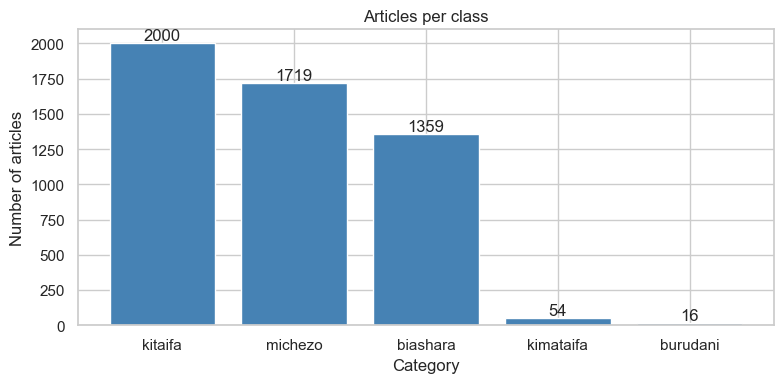

In [10]:
plt.figure(figsize=(8, 4))
bars = plt.bar(class_counts.index, class_counts.values, color="steelblue")
plt.bar_label(bars)
plt.title("Articles per class")
plt.xlabel("Category")
plt.ylabel("Number of articles")
save_figure("class_distribution.png")

In [11]:
largest_class = class_counts.max()
smallest_class = class_counts.min()
print(f"Imbalance ratio (largest / smallest): {largest_class / smallest_class:.0f} to 1")

Imbalance ratio (largest / smallest): 125 to 1


In [12]:
split_counts = pd.DataFrame({
    "train": train["category"].value_counts(),
    "validation": validation["category"].value_counts(),
    "test": test["category"].value_counts(),
})
split_counts

,train,validation,test
category,,,
kitaifa,1400,300,300
michezo,1203,258,258
biashara,951,204,204
kimataifa,38,8,8
burudani,11,2,3


**What this means for our models**

- The data is heavily imbalanced. `kimataifa` and `burudani` together are under 1.5% of articles.
- Accuracy would be misleading: a model that never predicts the two rare classes still scores about 98.7% accuracy. We use **macro-F1**, which weighs every class equally, and **log loss**, which is what Zindi uses to score submissions.
- We use **stratified splits** so every split contains the rare classes. Even so, the validation set has only 2 `burudani` articles, so scores on the rare classes will be unstable. We should state this as a limitation.
- Every model owner should try **class weights** as an experiment.

## 4. Article length

In [13]:
all_labelled["word_count"] = all_labelled["content"].apply(data_cleaning.count_words)
zindi_test["word_count"] = zindi_test["content"].apply(data_cleaning.count_words)

all_labelled["word_count"].describe().round(0)

count    5148.0
mean      320.0
std       196.0
min        31.0
25%       203.0
50%       276.0
75%       374.0
max      2597.0
Name: word_count, dtype: float64

In [14]:
length_by_class = all_labelled.groupby("category")["word_count"].describe()
length_by_class[["count", "mean", "50%", "max"]].round(0)

,count,mean,50%,max
category,,,,
biashara,1359.0,267.0,238.0,1581.0
burudani,16.0,73.0,66.0,149.0
kimataifa,54.0,169.0,138.0,583.0
kitaifa,2000.0,381.0,328.0,2597.0
michezo,1719.0,299.0,258.0,2220.0


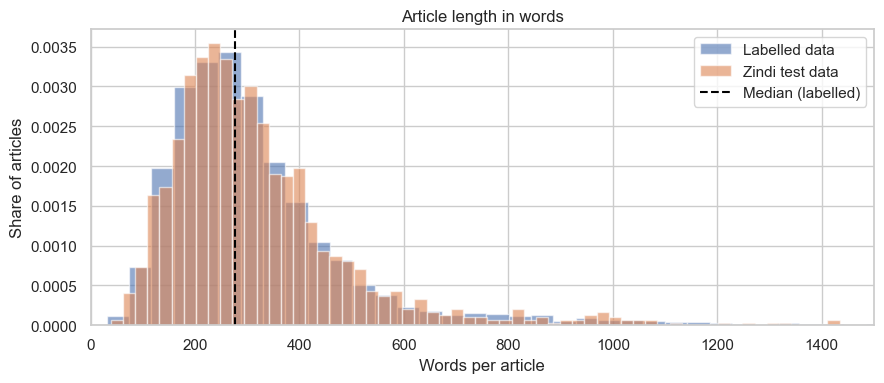

In [15]:
plt.figure(figsize=(9, 4))
plt.hist(all_labelled["word_count"], bins=60, alpha=0.6, density=True, label="Labelled data")
plt.hist(zindi_test["word_count"], bins=60, alpha=0.6, density=True, label="Zindi test data")
plt.axvline(all_labelled["word_count"].median(), color="black", linestyle="--", label="Median (labelled)")
plt.xlim(0, 1500)
plt.title("Article length in words")
plt.xlabel("Words per article")
plt.ylabel("Share of articles")
plt.legend()
save_figure("article_length_histogram.png")

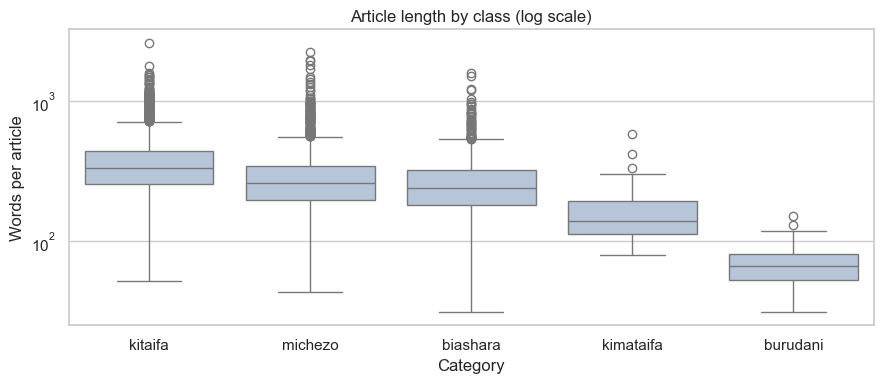

In [16]:
class_order = config.LABELS

plt.figure(figsize=(9, 4))
sns.boxplot(data=all_labelled, x="category", y="word_count", order=class_order, color="lightsteelblue")
plt.yscale("log")
plt.title("Article length by class (log scale)")
plt.xlabel("Category")
plt.ylabel("Words per article")
save_figure("article_length_by_class.png")

In [17]:
for word_limit in [100, 200, 300, 400]:
    share_longer = (all_labelled["word_count"] > word_limit).mean() * 100
    print(f"Articles longer than {word_limit} words: {share_longer:.1f}%")

Articles longer than 100 words: 97.8%
Articles longer than 200 words: 75.8%
Articles longer than 300 words: 42.3%
Articles longer than 400 words: 20.7%


**What this means for our models**

- Articles are long for sequence models: the median is around 270 words, with a long tail up to 2,500.
- Neural models need a fixed maximum length. Cutting at a sensible length keeps most articles whole without wasting memory on padding.
- Plain RNNs struggle to remember information across hundreds of steps, which supports using a **BiLSTM with attention** rather than a plain LSTM.
- The rare classes are **shorter** than the big classes. Length alone could be a clue for the classifier, which is worth checking in the error analysis.
- The Zindi test set has a very similar length distribution to our labelled data, so our splits look representative.

## 5. Subword token length (for the transformer)

Transformers do not read words. They read **subword tokens**, and most can only take 512 at a time. We compare two tokenizers on our articles: XLM-R (100 languages) and AfriBERTa (African languages only).

In [18]:
from transformers import AutoTokenizer

tokenizer_names = {
    "XLM-R": "xlm-roberta-base",
    "AfriBERTa": "castorini/afriberta_large",
}

tokenizers = {}
for short_name, model_name in tokenizer_names.items():
    tokenizers[short_name] = AutoTokenizer.from_pretrained(model_name)

/Users/michael/.pyenv/versions/3.10.19/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [19]:
example_sentence = "Serikali imesema haitakuwa tayari kuona amani ikichezewa"

for short_name, tokenizer in tokenizers.items():
    print(short_name, tokenizer.tokenize(example_sentence))

XLM-R ['▁Serikali', '▁i', 'mesema', '▁hai', 'takuwa', '▁tayari', '▁kuona', '▁amani', '▁iki', 'che', 'ze', 'wa']
AfriBERTa ['▁Serikali', '▁imesema', '▁haitakuwa', '▁tayari', '▁kuona', '▁amani', '▁iki', 'cheze', 'wa']


In [20]:
def count_tokens(tokenizer, text):
    token_ids = tokenizer(text, add_special_tokens=True)["input_ids"]
    return len(token_ids)


for short_name, tokenizer in tokenizers.items():
    column_name = f"{short_name}_tokens"
    all_labelled[column_name] = all_labelled["content"].apply(lambda text: count_tokens(tokenizer, text))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2159 > 512). Running this sequence through the model will result in indexing errors


In [21]:
transformer_limit = 512
token_rows = []

for short_name in tokenizers:
    token_counts = all_labelled[f"{short_name}_tokens"]
    tokens_per_word = token_counts.sum() / all_labelled["word_count"].sum()
    share_too_long = (token_counts > transformer_limit).mean() * 100

    token_rows.append({
        "tokenizer": short_name,
        "median_tokens": int(token_counts.median()),
        "tokens_per_word": round(tokens_per_word, 2),
        "percent_over_512_tokens": round(share_too_long, 1),
    })

token_table = pd.DataFrame(token_rows)
token_table

,tokenizer,median_tokens,tokens_per_word,percent_over_512_tokens
0,XLM-R,427,1.56,34.7
1,AfriBERTa,374,1.38,25.6


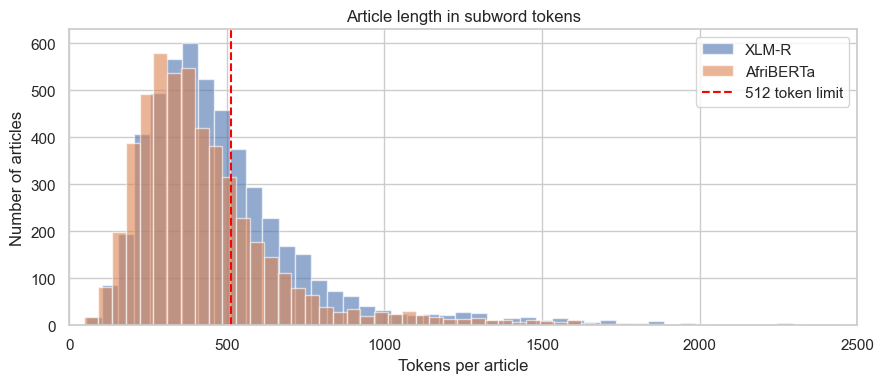

In [22]:
plt.figure(figsize=(9, 4))
for short_name in tokenizers:
    plt.hist(all_labelled[f"{short_name}_tokens"], bins=80, alpha=0.6, label=short_name)
plt.axvline(transformer_limit, color="red", linestyle="--", label="512 token limit")
plt.xlim(0, 2500)
plt.title("Article length in subword tokens")
plt.xlabel("Tokens per article")
plt.ylabel("Number of articles")
plt.legend()
save_figure("token_length_histogram.png")

**What this means for our models**

- AfriBERTa splits Swahili into fewer, more meaningful pieces than XLM-R (for example `imesema` stays whole instead of `i` + `mesema`). A tokenizer built for African languages fits our data better.
- Fewer tokens per word means more of each article fits inside the 512 token limit.
- A share of articles is still longer than 512 tokens, so the transformer experiments should compare ways of handling long articles (keep the start only, keep the start and end, or split into chunks).

## 6. Vocabulary and rare words

In [23]:
def get_words(text):
    return re.findall(r"[a-z]+", text.lower())


train_word_counts = Counter()
for text in train["content"]:
    train_word_counts.update(get_words(text))

vocabulary_size = len(train_word_counts)
total_words = sum(train_word_counts.values())
words_seen_once = [word for word, count in train_word_counts.items() if count == 1]

print(f"Total words in train: {total_words:,}")
print(f"Unique words in train: {vocabulary_size:,}")
print(f"Words that appear only once: {len(words_seen_once):,} ({len(words_seen_once) / vocabulary_size * 100:.1f}% of the vocabulary)")

Total words in train: 1,136,760
Unique words in train: 58,936
Words that appear only once: 31,755 (53.9% of the vocabulary)


In [24]:
validation_words = []
for text in validation["content"]:
    validation_words.extend(get_words(text))

unseen_words = [word for word in validation_words if word not in train_word_counts]
unseen_share = len(unseen_words) / len(validation_words) * 100

print(f"Validation words never seen in train: {unseen_share:.1f}%")
print("Examples:", Counter(unseen_words).most_common(15))

Validation words never seen in train: 3.6%
Examples: [('salvador', 18), ('honduras', 14), ('sagcot', 11), ('taekwondo', 11), ('fisi', 11), ('gabagambi', 9), ('tunutu', 8), ('milk', 8), ('rohr', 7), ('tcrs', 7), ('liuli', 7), ('joho', 7), ('volkswagen', 6), ('nuh', 6), ('oxide', 6)]


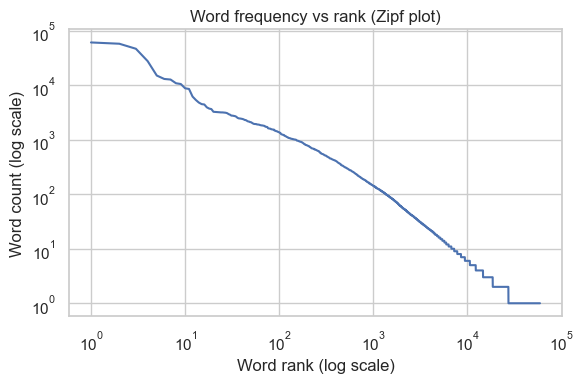

In [25]:
sorted_counts = sorted(train_word_counts.values(), reverse=True)
word_ranks = np.arange(1, len(sorted_counts) + 1)

plt.figure(figsize=(6, 4))
plt.loglog(word_ranks, sorted_counts)
plt.title("Word frequency vs rank (Zipf plot)")
plt.xlabel("Word rank (log scale)")
plt.ylabel("Word count (log scale)")
save_figure("zipf_plot.png")

**What this means for our models**

- The vocabulary is large and long-tailed: a big share of words appear only once. Swahili builds words by adding prefixes and suffixes to a root (`ali-sema`, `wa-li-sema`, `ha-ta-sema`), so one root turns into many different surface words.
- Word-level models (TF-IDF, CNN and BiLSTM with a word vocabulary) will meet unseen words in validation and test. They need a minimum word frequency or an `<unknown>` token.
- Subword tokenizers (the transformer) and subword embeddings like fastText handle unseen word forms better, because they can build a new word from known pieces.

## 7. Common words and distinctive words per class

In [26]:
most_common_words = pd.DataFrame(train_word_counts.most_common(20), columns=["word", "count"])
most_common_words

,word,count
0,ya,60918
1,na,57712
2,wa,46661
3,kwa,27663
4,katika,15059
5,za,13034
6,alisema,12718
7,ni,10871
8,la,10519
9,hiyo,8784


The most frequent words (`na`, `ya`, `wa`, `kwa`, `katika`) are function words that appear in every article, so they say nothing about the topic. **TF-IDF** automatically gives them low weight, so we do not need a Swahili stopword list, which is hard to find for a low-resource language.

In [27]:
def count_words_in_class(data, category):
    class_counts = Counter()
    class_texts = data[data["category"] == category]["content"]
    for text in class_texts:
        class_counts.update(get_words(text))
    return class_counts


def find_distinctive_words(data, category, top_n=10, minimum_count=3):
    class_counts = count_words_in_class(data, category)
    other_counts = Counter()
    for other_category in config.LABELS:
        if other_category != category:
            other_counts.update(count_words_in_class(data, other_category))

    total_class_words = sum(class_counts.values())
    total_other_words = sum(other_counts.values())

    scores = {}
    for word, count in class_counts.items():
        if count < minimum_count:
            continue
        rate_in_class = (count + 1) / total_class_words
        rate_in_others = (other_counts[word] + 1) / total_other_words
        scores[word] = rate_in_class / rate_in_others

    best_words = sorted(scores, key=scores.get, reverse=True)
    return best_words[:top_n]

In [28]:
distinctive_words = {}
for category in config.LABELS:
    distinctive_words[category] = find_distinctive_words(train, category)

pd.DataFrame(distinctive_words)

,kitaifa,michezo,biashara,kimataifa,burudani
0,vvu,arsenal,zstc,shamima,professor
1,shehe,kumsajili,karafuu,javid,brown
2,mtuhumiwa,liverpool,nagu,ndevu,wayne
3,lissu,tottenham,yatosha,mutharika,rapa
4,masauni,mail,tccia,nyuklia,mwanamuziki
5,ufaulu,mirror,kinana,bangladesh,studio
6,igp,juventus,dse,putin,miss
7,ukatili,kumsaini,muhongo,ndegevita,jay
8,ukoma,sports,atm,schutte,chris
9,risasi,winga,vicoba,snoop,mikumi


**What this means for our models**

- Each big class has clear topic keywords (club and player names for `michezo`, money and market words for `biashara`). This is why a bag-of-words baseline is likely to be strong: many articles can be classified from single words, without word order.
- Some `michezo` keywords (`mail`, `mirror`, `sports`) are British newspaper names. These look like football transfer gossip round-ups quoting the Daily Mail and the Mirror, which is another sign that some sports articles come from a different source.
- The rare classes have much less evidence. With only 11 training articles, the distinctive words for `burudani` are likely to be names from those few articles rather than general entertainment vocabulary. This is where pretraining should help most.
- `kitaifa` (national) and `kimataifa` (international) cover similar topics (politics, government, economy) and differ mostly by **where** the story happens. We expect these two to be confused, which the error analysis should check.

## 8. Summary of findings

| Finding | Evidence | Decision |
|---|---|---|
| List formatting only in sports articles | Section 2 crosstab | Unwrap lists in cleaning so models cannot use formatting as a shortcut |
| Glued sentences in most articles | Section 2 | Add a space after full stops |
| Heavy class imbalance | Section 3 | Macro-F1 and log loss, stratified splits, class weight experiments |
| Very few rare-class examples in validation and test | Section 3 | Report per-class scores and treat rare-class results with caution |
| Long articles (median about 270 words) | Section 4 | Attention on top of the BiLSTM; choose max length from the length distribution |
| Many articles over 512 subword tokens | Section 5 | Compare truncation and chunking strategies for the transformer |
| AfriBERTa tokenizes Swahili more efficiently | Section 5 | Compare AfriBERTa with XLM-R |
| Large, long-tailed vocabulary | Section 6 | Minimum word frequency for word models; subword models expected to generalise better |
| Frequent function words, clear topic keywords | Section 7 | TF-IDF baselines are a meaningful comparison |